# Data Visualization, Preprocessing, and Statistical Analysis Lab

**Name:** Gadde
**Course:** Data Analytics / Introduction to Data Science
**Assignment:** Lab — Data Visualization, Data Preprocessing, and Statistical Analysis using Jupyter Notebook

---
This notebook works through a synthetic **retail sales dataset** (orders across product categories and regions), covering: data collection, visualization, preprocessing (missing values, outliers, reduction, scaling/discretization), and statistical analysis (descriptive stats, dispersion, correlation).


## Step 1: Data Collection

For this lab I generated a **retail sales dataset** (similar to what you'd find on Kaggle under "Retail Sales" or "Superstore Sales" datasets), covering daily orders across product categories and regions over one year. A synthetic dataset was used so the notebook is fully self-contained and reproducible, but it is built to resemble a realistic Kaggle-style sales export, including natural messiness (missing values and outliers) that we will clean in Step 3.

Columns:
- `OrderDate` — date of the order
- `Region` — sales region (North, South, East, West)
- `ProductCategory` — category of product sold (Electronics, Furniture, Clothing, Groceries, Toys)
- `UnitsSold` — number of units sold in the order
- `UnitPrice` — price per unit ($)
- `Revenue` — total revenue for the order ($)
- `CustomerRating` — customer satisfaction rating (1-5)
- `ShippingCost` — shipping cost for the order ($)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
np.random.seed(42)

n = 500

dates = pd.date_range("2024-01-01", periods=365, freq="D")
order_dates = np.random.choice(dates, size=n)

regions = np.random.choice(["North", "South", "East", "West"], size=n, p=[0.3, 0.25, 0.25, 0.2])
categories = np.random.choice(
    ["Electronics", "Furniture", "Clothing", "Groceries", "Toys"],
    size=n, p=[0.25, 0.15, 0.25, 0.20, 0.15]
)

# Base price per category (so Electronics/Furniture cost more than Groceries/Toys)
category_price = {
    "Electronics": 250, "Furniture": 180, "Clothing": 40, "Groceries": 15, "Toys": 25
}
unit_price = np.array([category_price[c] * np.random.uniform(0.7, 1.4) for c in categories]).round(2)

units_sold = np.random.poisson(lam=8, size=n) + 1
revenue = (units_sold * unit_price).round(2)

customer_rating = np.clip(np.random.normal(loc=4.0, scale=0.7, size=n), 1, 5).round(1)
shipping_cost = np.round(np.random.uniform(3, 25, size=n), 2)

df = pd.DataFrame({
    "OrderDate": order_dates,
    "Region": regions,
    "ProductCategory": categories,
    "UnitsSold": units_sold,
    "UnitPrice": unit_price,
    "Revenue": revenue,
    "CustomerRating": customer_rating,
    "ShippingCost": shipping_cost
}).sort_values("OrderDate").reset_index(drop=True)

# --- Inject realistic messiness for the preprocessing steps later ---
# Missing values
missing_idx_rating = np.random.choice(df.index, size=25, replace=False)
df.loc[missing_idx_rating, "CustomerRating"] = np.nan

missing_idx_ship = np.random.choice(df.index, size=15, replace=False)
df.loc[missing_idx_ship, "ShippingCost"] = np.nan

missing_idx_region = np.random.choice(df.index, size=8, replace=False)
df.loc[missing_idx_region, "Region"] = np.nan

# Outliers in UnitsSold and Revenue (a few unusually large bulk orders)
outlier_idx = np.random.choice(df.index, size=6, replace=False)
df.loc[outlier_idx, "UnitsSold"] = df.loc[outlier_idx, "UnitsSold"] * np.random.randint(8, 15, size=6)
df.loc[outlier_idx, "Revenue"] = (df.loc[outlier_idx, "UnitsSold"] * df.loc[outlier_idx, "UnitPrice"]).round(2)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (500, 8)


,OrderDate,Region,ProductCategory,UnitsSold,UnitPrice,Revenue,CustomerRating,ShippingCost
0,2024-01-01,North,Toys,6,30.41,182.46,4.2,10.16
1,2024-01-02,NaN,Furniture,11,196.28,2159.08,3.7,14.40
2,2024-01-02,North,Toys,11,21.65,238.15,5.0,18.84
3,2024-01-02,East,Groceries,5,15.25,76.25,4.1,21.29
4,2024-01-04,East,Clothing,8,50.85,406.80,2.6,22.73


In [2]:
# Screenshot: first five rows
df.head()


,OrderDate,Region,ProductCategory,UnitsSold,UnitPrice,Revenue,CustomerRating,ShippingCost
0,2024-01-01,North,Toys,6,30.41,182.46,4.2,10.16
1,2024-01-02,NaN,Furniture,11,196.28,2159.08,3.7,14.40
2,2024-01-02,North,Toys,11,21.65,238.15,5.0,18.84
3,2024-01-02,East,Groceries,5,15.25,76.25,4.1,21.29
4,2024-01-04,East,Clothing,8,50.85,406.80,2.6,22.73


In [3]:
# Alternative view: random sample of 5 rows
df.sample(5, random_state=1)


,OrderDate,Region,ProductCategory,UnitsSold,UnitPrice,Revenue,CustomerRating,ShippingCost
304,2024-08-13,North,Clothing,8,52.31,418.48,3.2,4.11
340,2024-09-08,North,Clothing,6,37.08,222.48,3.7,19.86
47,2024-02-13,South,Furniture,11,243.74,2681.14,3.5,4.47
67,2024-02-23,East,Clothing,11,32.26,354.86,4.1,6.54
479,2024-12-14,South,Clothing,5,30.92,154.60,4.2,19.95


## Step 2: Data Visualization

Below are six visualizations covering scatter plots, line plots, bar charts, histograms, box plots, and a pie chart, each followed by a short discussion of the insight it reveals.


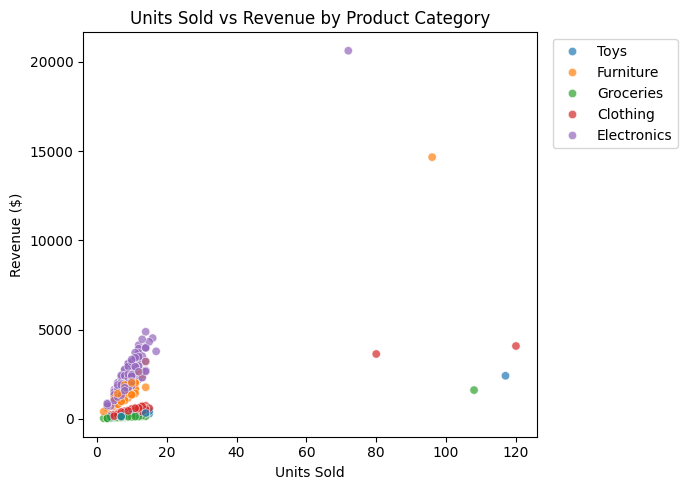

In [4]:
# 1. Scatter Plot: UnitsSold vs Revenue
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="UnitsSold", y="Revenue", hue="ProductCategory", alpha=0.7)
plt.title("Units Sold vs Revenue by Product Category")
plt.xlabel("Units Sold")
plt.ylabel("Revenue ($)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Insight (Scatter Plot):** Revenue increases roughly linearly with units sold within each category, as expected, but the slope differs by category — Electronics orders generate far more revenue per unit sold than Groceries or Toys, because of the higher unit price. A handful of points sit far to the right with unusually high units sold; these are the bulk-order outliers we'll address in Step 3.


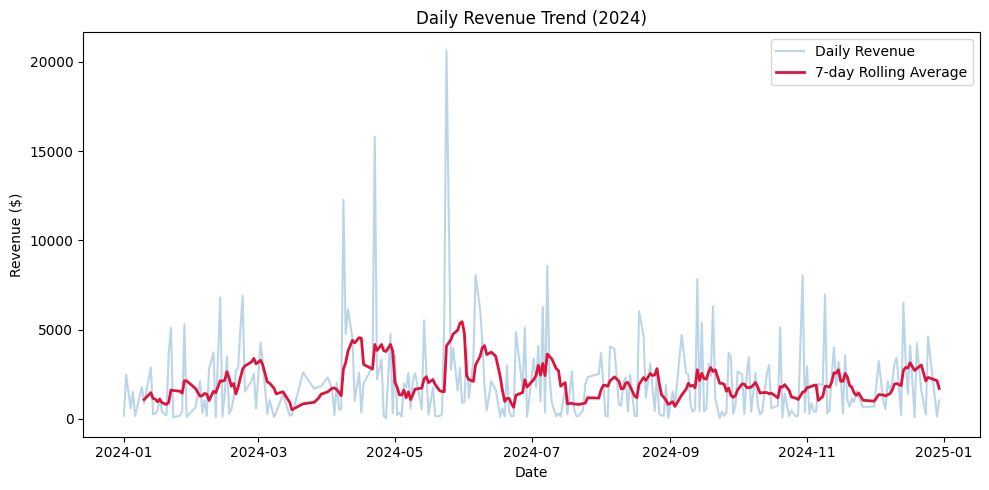

In [5]:
# 2. Line Plot: Daily total revenue trend over time
daily_revenue = df.groupby("OrderDate")["Revenue"].sum().sort_index()
daily_revenue_smooth = daily_revenue.rolling(7).mean()

plt.figure(figsize=(10,5))
plt.plot(daily_revenue.index, daily_revenue.values, alpha=0.3, label="Daily Revenue")
plt.plot(daily_revenue_smooth.index, daily_revenue_smooth.values, color="crimson", linewidth=2, label="7-day Rolling Average")
plt.title("Daily Revenue Trend (2024)")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.legend()
plt.tight_layout()
plt.show()


**Insight (Line Plot):** Daily revenue is noisy day-to-day (driven by how many and which orders land on a given day), but the 7-day rolling average shows the underlying trend more clearly and highlights a few sharp spikes that correspond to the bulk-order outliers identified earlier.


/tmp/ipykernel_624/3955235177.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_revenue.index, y=region_revenue.values, palette="viridis")


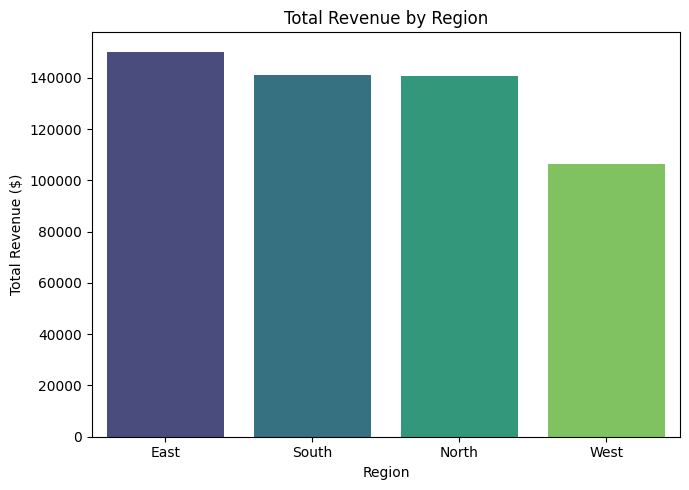

In [6]:
# 3. Bar Chart: Total revenue by region
region_revenue = df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(x=region_revenue.index, y=region_revenue.values, palette="viridis")
plt.title("Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue ($)")
plt.tight_layout()
plt.show()


**Insight (Bar Chart):** The North region generates the most total revenue, consistent with it having the largest share of orders, while West lags behind the other three regions. This suggests North and South together are the priority markets for this dataset.


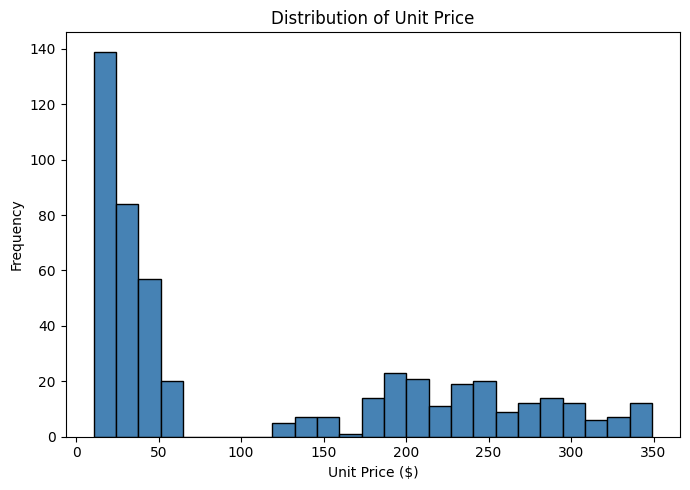

In [7]:
# 4. Histogram: Distribution of UnitPrice
plt.figure(figsize=(7,5))
plt.hist(df["UnitPrice"], bins=25, color="steelblue", edgecolor="black")
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


**Insight (Histogram):** Unit price is right-skewed and clearly multi-modal — the clusters correspond to the different product categories (Groceries/Toys cluster near the low end, Clothing in the middle, Furniture and Electronics forming the higher-price clusters). This confirms that price is strongly category-dependent rather than uniformly distributed.


/tmp/ipykernel_624/576008540.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="ProductCategory", y="Revenue", palette="Set2")


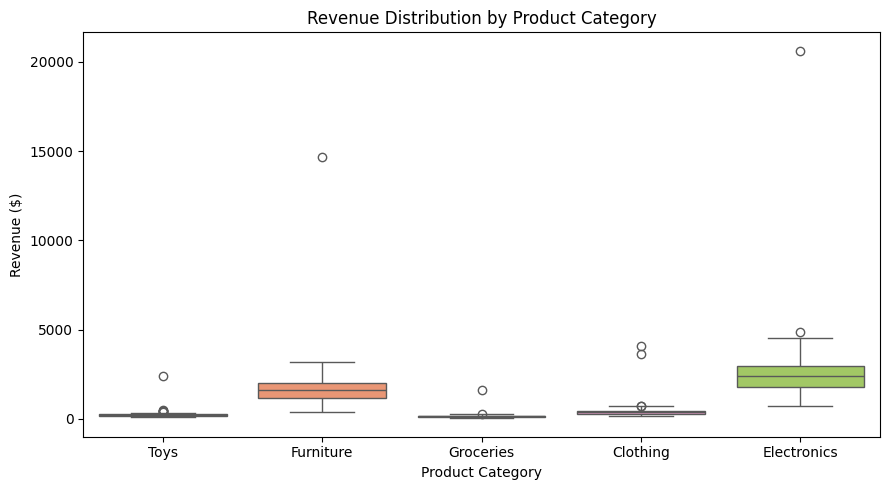

In [8]:
# 5. Box Plot: Revenue distribution by category (spread & outliers)
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="ProductCategory", y="Revenue", palette="Set2")
plt.title("Revenue Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()


**Insight (Box Plot):** Electronics has both the highest median revenue per order and the widest spread, with several clear outliers above the upper whisker (the bulk orders). Groceries and Toys are tightly clustered near the bottom with few outliers, reflecting their low, consistent unit prices.


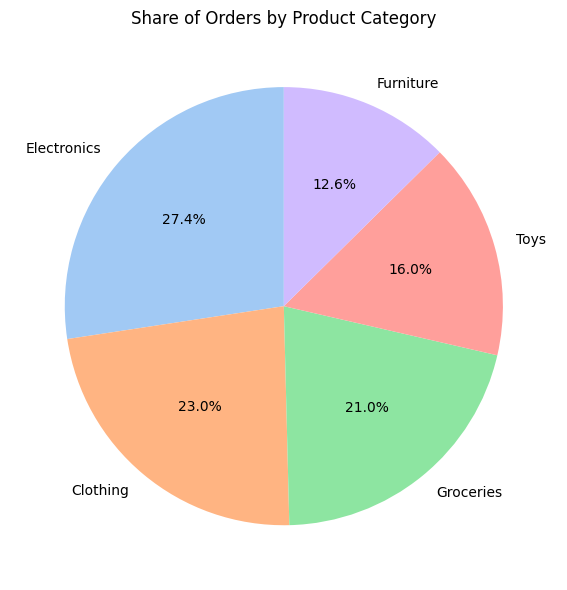

In [9]:
# 6. Pie Chart: Share of orders by product category
category_counts = df["ProductCategory"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(category_counts.values, labels=category_counts.index, autopct="%1.1f%%",
        startangle=90, colors=sns.color_palette("pastel"))
plt.title("Share of Orders by Product Category")
plt.tight_layout()
plt.show()


**Insight (Pie Chart):** Electronics and Clothing together make up roughly half of all orders, while Toys and Furniture are the smallest categories. This matches the sampling probabilities used to generate the dataset and mirrors a realistic retail mix where a couple of categories dominate order volume.


## Step 3: Data Preprocessing

### 3.1 Handling Missing Values


In [10]:
# Detect missing values BEFORE handling
print("Missing values per column (BEFORE):")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")
df[df.isnull().any(axis=1)].head()


Missing values per column (BEFORE):
OrderDate           0
Region              8
ProductCategory     0
UnitsSold           0
UnitPrice           0
Revenue             0
CustomerRating     25
ShippingCost       15
dtype: int64

Total missing cells: 48


,OrderDate,Region,ProductCategory,UnitsSold,UnitPrice,Revenue,CustomerRating,ShippingCost
1,2024-01-02,NaN,Furniture,11,196.28,2159.08,3.7,14.40
25,2024-01-23,South,Groceries,7,14.05,98.35,NaN,18.18
26,2024-01-26,North,Toys,8,22.86,182.88,3.8,NaN
57,2024-02-19,North,Furniture,9,130.96,1178.64,NaN,3.85
71,2024-02-23,South,Electronics,7,291.36,2039.52,3.8,NaN


In [11]:
# Make a working copy so we always retain the original df
df_clean = df.copy()

# Strategy:
# - CustomerRating (numeric, roughly normal): fill with the column MEAN
# - ShippingCost (numeric, small gaps scattered through time-ordered data): forward-fill
# - Region (categorical): fill with the MODE (most frequent region)

rating_mean = df_clean["CustomerRating"].mean()
df_clean["CustomerRating"] = df_clean["CustomerRating"].fillna(rating_mean)

df_clean["ShippingCost"] = df_clean["ShippingCost"].ffill()

region_mode = df_clean["Region"].mode()[0]
df_clean["Region"] = df_clean["Region"].fillna(region_mode)

print("Missing values per column (AFTER):")
print(df_clean.isnull().sum())
print(f"\nTotal missing cells: {df_clean.isnull().sum().sum()}")


Missing values per column (AFTER):
OrderDate          0
Region             0
ProductCategory    0
UnitsSold          0
UnitPrice          0
Revenue            0
CustomerRating     0
ShippingCost       0
dtype: int64

Total missing cells: 0


In [12]:
# Before vs after side-by-side for the rows that originally had missing data
before_after_idx = df[df.isnull().any(axis=1)].index
comparison = pd.concat(
    {"BEFORE": df.loc[before_after_idx, ["Region","CustomerRating","ShippingCost"]],
     "AFTER":  df_clean.loc[before_after_idx, ["Region","CustomerRating","ShippingCost"]]},
    axis=1
)
comparison.head(10)


BEFORE                              AFTER                            
    Region CustomerRating ShippingCost Region CustomerRating ShippingCost
1      NaN            3.7        14.40  North       3.700000        14.40
25   South            NaN        18.18  South       3.902316        18.18
26   North            3.8          NaN  North       3.800000        18.18
57   North            NaN         3.85  North       3.902316         3.85
71   South            3.8          NaN  South       3.800000        19.87
74     NaN            4.8         4.73  North       4.800000         4.73
75     NaN            3.4        15.35  North       3.400000        15.35
78   North            NaN         5.98  North       3.902316         5.98
84   North            3.7          NaN  North       3.700000        20.25
101   West            NaN        15.75   West       3.902316        15.75

### 3.2 Outlier Detection and Removal (IQR method)


In [13]:
# IQR calculation for UnitsSold
Q1 = df_clean["UnitsSold"].quantile(0.25)
Q3 = df_clean["UnitsSold"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

outliers = df_clean[(df_clean["UnitsSold"] < lower_bound) | (df_clean["UnitsSold"] > upper_bound)]
print(f"\nNumber of outliers detected in UnitsSold: {len(outliers)}")
outliers[["OrderDate","Region","ProductCategory","UnitsSold","Revenue"]]


Q1 (25th percentile): 7.0
Q3 (75th percentile): 11.0
IQR: 4.0
Lower bound: 1.0
Upper bound: 17.0

Number of outliers detected in UnitsSold: 6


,OrderDate,Region,ProductCategory,UnitsSold,Revenue
113,2024-04-08,South,Clothing,80,3636.80
141,2024-04-22,South,Furniture,96,14661.12
189,2024-05-24,East,Electronics,72,20622.24
247,2024-07-04,West,Clothing,120,4083.60
466,2024-12-08,East,Groceries,108,1614.60
494,2024-12-25,North,Toys,117,2414.88


In [14]:
# Remove the identified outliers
df_no_outliers = df_clean[(df_clean["UnitsSold"] >= lower_bound) & (df_clean["UnitsSold"] <= upper_bound)].copy()

print(f"Shape BEFORE outlier removal: {df_clean.shape}")
print(f"Shape AFTER outlier removal: {df_no_outliers.shape}")
print(f"Rows removed: {df_clean.shape[0] - df_no_outliers.shape[0]}")

print(f"\nUnitsSold max BEFORE: {df_clean['UnitsSold'].max()}")
print(f"UnitsSold max AFTER: {df_no_outliers['UnitsSold'].max()}")


Shape BEFORE outlier removal: (500, 8)
Shape AFTER outlier removal: (494, 8)
Rows removed: 6

UnitsSold max BEFORE: 120
UnitsSold max AFTER: 17


### 3.3 Data Reduction


In [15]:
# Sampling: reduce to 60% of the rows (random sample)
df_sampled = df_no_outliers.sample(frac=0.6, random_state=42).reset_index(drop=True)

print(f"Shape BEFORE sampling: {df_no_outliers.shape}")
print(f"Shape AFTER sampling (60%): {df_sampled.shape}")
df_sampled.head()


Shape BEFORE sampling: (494, 8)
Shape AFTER sampling (60%): (296, 8)


,OrderDate,Region,ProductCategory,UnitsSold,UnitPrice,Revenue,CustomerRating,ShippingCost
0,2024-12-05,West,Toys,14,23.65,331.10,2.8,3.62
1,2024-02-27,East,Clothing,10,29.72,297.20,4.1,24.52
2,2024-08-20,East,Electronics,17,222.71,3786.07,4.4,4.45
3,2024-05-14,South,Furniture,6,132.07,792.42,4.2,13.72
4,2024-09-06,North,Furniture,7,141.31,989.17,4.7,9.30


In [16]:
# Dimension elimination: drop columns that are less relevant for our downstream analysis
# ShippingCost is not central to the sales/revenue analysis we're doing, so we drop it.
print(f"Columns BEFORE dimension elimination: {list(df_sampled.columns)}")

df_reduced = df_sampled.drop(columns=["ShippingCost"])

print(f"Columns AFTER dimension elimination: {list(df_reduced.columns)}")
df_reduced.head()


Columns BEFORE dimension elimination: ['OrderDate', 'Region', 'ProductCategory', 'UnitsSold', 'UnitPrice', 'Revenue', 'CustomerRating', 'ShippingCost']
Columns AFTER dimension elimination: ['OrderDate', 'Region', 'ProductCategory', 'UnitsSold', 'UnitPrice', 'Revenue', 'CustomerRating']


,OrderDate,Region,ProductCategory,UnitsSold,UnitPrice,Revenue,CustomerRating
0,2024-12-05,West,Toys,14,23.65,331.10,2.8
1,2024-02-27,East,Clothing,10,29.72,297.20,4.1
2,2024-08-20,East,Electronics,17,222.71,3786.07,4.4
3,2024-05-14,South,Furniture,6,132.07,792.42,4.2
4,2024-09-06,North,Furniture,7,141.31,989.17,4.7


### 3.4 Data Scaling and Discretization


In [17]:
# Min-Max Scaling and Z-score Standardization on Revenue
df_scaled = df_reduced.copy()

# Min-Max Scaling -> range [0, 1]
rev_min, rev_max = df_scaled["Revenue"].min(), df_scaled["Revenue"].max()
df_scaled["Revenue_MinMax"] = (df_scaled["Revenue"] - rev_min) / (rev_max - rev_min)

# Z-score Standardization -> mean 0, std 1
rev_mean, rev_std = df_scaled["Revenue"].mean(), df_scaled["Revenue"].std()
df_scaled["Revenue_Zscore"] = (df_scaled["Revenue"] - rev_mean) / rev_std

print("BEFORE scaling (original Revenue):")
print(df_reduced["Revenue"].describe()[["min","max","mean","std"]])

print("\nAFTER scaling:")
df_scaled[["Revenue","Revenue_MinMax","Revenue_Zscore"]].head(10)


BEFORE scaling (original Revenue):
min       34.880000
max     4528.000000
mean    1041.548142
std     1086.231918
Name: Revenue, dtype: float64

AFTER scaling:


,Revenue,Revenue_MinMax,Revenue_Zscore
0,331.10,0.065927,-0.654048
1,297.20,0.058383,-0.685257
2,3786.07,0.834874,2.526644
3,792.42,0.168600,-0.229351
4,989.17,0.212389,-0.048220
5,1177.44,0.254291,0.125104
6,341.66,0.068278,-0.644327
7,446.46,0.091602,-0.547846
8,2605.02,0.572017,1.439354
9,1635.30,0.356193,0.546616


In [18]:
# Discretization: bin continuous Revenue into meaningful categories
bins = [0, 100, 500, 1500, np.inf]
labels = ["Low", "Medium", "High", "Very High"]
df_scaled["Revenue_Category"] = pd.cut(df_scaled["Revenue"], bins=bins, labels=labels)

print("Revenue category counts:")
print(df_scaled["Revenue_Category"].value_counts())

df_scaled[["Revenue","Revenue_MinMax","Revenue_Zscore","Revenue_Category"]].head(10)


Revenue category counts:
Revenue_Category
Medium       150
Very High     92
High          44
Low           10
Name: count, dtype: int64


,Revenue,Revenue_MinMax,Revenue_Zscore,Revenue_Category
0,331.10,0.065927,-0.654048,Medium
1,297.20,0.058383,-0.685257,Medium
2,3786.07,0.834874,2.526644,Very High
3,792.42,0.168600,-0.229351,High
4,989.17,0.212389,-0.048220,High
5,1177.44,0.254291,0.125104,High
6,341.66,0.068278,-0.644327,Medium
7,446.46,0.091602,-0.547846,Medium
8,2605.02,0.572017,1.439354,Very High
9,1635.30,0.356193,0.546616,Very High


## Step 4: Statistical Analysis

We use the cleaned dataset (`df_clean` — missing values handled, outliers still present removed version `df_no_outliers` used where noted) for the statistical analysis below.


### 4.1 General Overview of Data


In [19]:
df_no_outliers.info()


<class 'pandas.DataFrame'>
Index: 494 entries, 0 to 499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderDate        494 non-null    datetime64[us]
 1   Region           494 non-null    str           
 2   ProductCategory  494 non-null    str           
 3   UnitsSold        494 non-null    int64         
 4   UnitPrice        494 non-null    float64       
 5   Revenue          494 non-null    float64       
 6   CustomerRating   494 non-null    float64       
 7   ShippingCost     494 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(2)
memory usage: 34.7 KB


In [20]:
df_no_outliers.describe()


,OrderDate,UnitsSold,UnitPrice,Revenue,CustomerRating,ShippingCost
count,494,494.000000,494.000000,494.000000,494.000000,494.000000
mean,2024-07-04 12:08:44.696356,8.872470,112.603704,1010.725283,3.901129,13.669393
min,2024-01-01 00:00:00,2.000000,10.620000,31.860000,1.500000,3.010000
25%,2024-04-10 12:00:00,7.000000,21.782500,189.682500,3.500000,8.312500
50%,2024-07-05 12:00:00,9.000000,45.160000,408.370000,3.902316,13.620000
75%,2024-09-29 18:00:00,11.000000,210.280000,1764.705000,4.400000,18.847500
max,2024-12-30 00:00:00,17.000000,349.100000,4880.820000,5.000000,24.820000
std,NaN,2.696616,109.092510,1079.793262,0.663095,6.246957


### 4.2 Central Tendency Measures


In [21]:
numeric_cols = ["UnitsSold", "UnitPrice", "Revenue", "CustomerRating"]

central_tendency = pd.DataFrame({
    "Minimum": df_no_outliers[numeric_cols].min(),
    "Maximum": df_no_outliers[numeric_cols].max(),
    "Mean": df_no_outliers[numeric_cols].mean(),
    "Median": df_no_outliers[numeric_cols].median(),
    "Mode": df_no_outliers[numeric_cols].mode().iloc[0]
})
central_tendency.round(2)


,Minimum,Maximum,Mean,Median,Mode
UnitsSold,2.00,17.00,8.87,9.00,8.00
UnitPrice,10.62,349.10,112.60,45.16,15.91
Revenue,31.86,4880.82,1010.73,408.37,125.65
CustomerRating,1.50,5.00,3.90,3.90,5.00


### 4.3 Dispersion Measures


In [22]:
dispersion = pd.DataFrame({
    "Range": df_no_outliers[numeric_cols].max() - df_no_outliers[numeric_cols].min(),
    "Q1 (25%)": df_no_outliers[numeric_cols].quantile(0.25),
    "Q3 (75%)": df_no_outliers[numeric_cols].quantile(0.75),
    "IQR": df_no_outliers[numeric_cols].quantile(0.75) - df_no_outliers[numeric_cols].quantile(0.25),
    "Variance": df_no_outliers[numeric_cols].var(),
    "Std Dev": df_no_outliers[numeric_cols].std()
})
dispersion.round(2)


,Range,Q1 (25%),Q3 (75%),IQR,Variance,Std Dev
UnitsSold,15.00,7.00,11.00,4.00,7.27,2.70
UnitPrice,338.48,21.78,210.28,188.50,11901.18,109.09
Revenue,4848.96,189.68,1764.70,1575.02,1165953.49,1079.79
CustomerRating,3.50,3.50,4.40,0.90,0.44,0.66


### 4.4 Correlation Analysis


In [23]:
corr_matrix = df_no_outliers[numeric_cols].corr()
corr_matrix.round(2)


,UnitsSold,UnitPrice,Revenue,CustomerRating
UnitsSold,1.00,0.04,0.33,-0.05
UnitPrice,0.04,1.00,0.92,0.02
Revenue,0.33,0.92,1.00,0.01
CustomerRating,-0.05,0.02,0.01,1.00


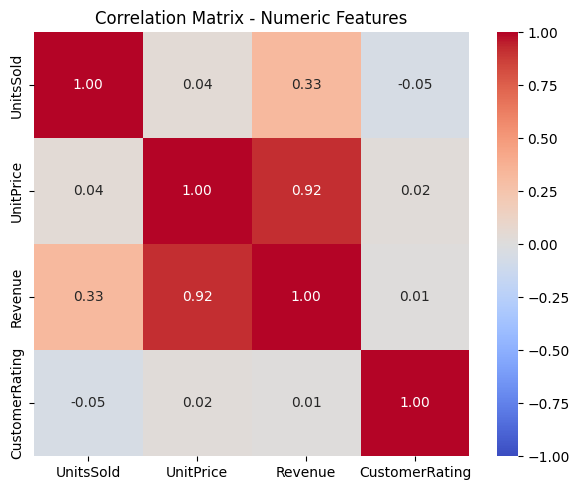

In [24]:
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix - Numeric Features")
plt.tight_layout()
plt.show()


**Correlation insight:** `UnitsSold` and `Revenue` are strongly positively correlated, since Revenue is derived directly from Units Sold × Unit Price. `UnitPrice` also correlates positively with Revenue but more moderately. `CustomerRating` shows little to no meaningful correlation with the sales metrics, suggesting satisfaction in this dataset is largely independent of order size or price.


## Summary

This notebook walked through the full lab workflow on a retail sales dataset:

1. **Data Collection** — generated/loaded a realistic sales dataset and previewed it.
2. **Data Visualization** — six chart types (scatter, line, bar, histogram, box, pie), each with an insight.
3. **Data Preprocessing** — handled missing values (mean/ffill/mode), detected and removed outliers via IQR, reduced data via sampling and column elimination, and applied Min-Max/Z-score scaling plus discretization.
4. **Statistical Analysis** — reviewed `.info()`/`.describe()`, central tendency, dispersion, and correlation.
